# Understanding the Segmenter

A step-by-step execution of the SPIRA segmenter code, with intermediary output visualizations.

 
The code can be run following the instructions in the README: https://github.com/SPIRA-COVID19/segmenter/

More details can be found [here](https://linux.ime.usp.br/~razgrizone/mac0499/monografia/) in section 3.1.1.

## Environment setup (Python packages and whatnots)

In [1]:
# Utilies
from os import listdir
from os.path import isfile, join
from IPython.display import display, Markdown

In [2]:
# Numerical packages
import matplotlib
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
plt.style.use("seaborn-whitegrid")

In [3]:
# Audio packages
import librosa
from IPython.display import Audio

In [4]:
# SPIRA packages
from common import Segmenter

## Data

In [5]:
# Data
INPUT_DIR = join("data", "input")
WAV_FILES = [f for f in listdir(INPUT_DIR)if f.endswith(".wav")]

filename = join(INPUT_DIR, WAV_FILES[0])

## Parameters

Straight from the original text and sourcecode, this parameters are here to be tweaked, iterated over and tested in a grid-search of sorts later.

In [6]:
# Constants
WINDOW_SIZE = 4096
MAX_DYNAMIC_RANGE = 90
NOISE_THRESHOLD_PCT = 0.27
NOISE_THRESHOLD_DB = None # off
BOOL_FILTER_WINDOW_SIZE=None # default: 0.2 * sample rate (200ms)

In [7]:
# Helper functions
def printmd(text):
    display(Markdown(text))

def show(signal, title="", subtitle="", xlabel="", ylabel="", ax=None, x=[], audio=False):
    x = np.arange(0, len(signal))
    
    if audio:
        display(Audio(signal.T, rate = SAMPLE_RATE))
        xlabel="[s]"
        x = np.arange(0, len(signal)/SAMPLE_RATE, 1/SAMPLE_RATE)

    if ax == None:
        plt.figure()
        plt.title(title)
        plt.xlabel(xlabel)
        plt.ylabel(ylabel)
        plt.plot(x, signal)
        plt.show()
    else:
        plt.suptitle(title)
        ax.set_title(subtitle)
        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)
        plt.plot(x, signal)
        plt.tight_layout()
        

## Running the segmenter

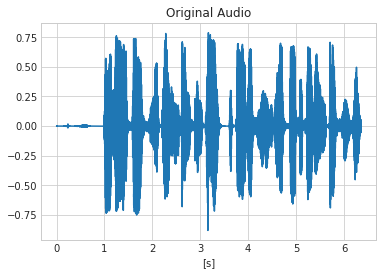

In [8]:
y, SAMPLE_RATE = librosa.load(filename)
x = np.arange(0, len(y)/SAMPLE_RATE, 1/SAMPLE_RATE)

show(y, title="Original Audio", audio=True)

### Removing the DC component

In [9]:
#     def __remove_dc(self, y):
#         """
#             Remove any DC from audio, centralizing it at 0 on the range of [-1, 1].
#         """
#         return y[:] - np.mean(y)

def remove_dc(y):
    y_without_dc = y - np.mean(y)
    show(y_without_dc, title="Audio after DC removal", audio = True)
    return y_without_dc

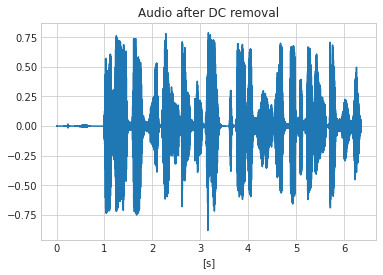

In [10]:
y_without_dc = remove_dc(y)

### Calculating the energy

As in section 3.1.1.

In [11]:
#     def __sliding_window_energy(self, y, sr, window_size=4096):
#         """
#             Calculates the mean energy (in dB) of the signal in sliding windows.
#             returns the mean energy edB and its minimum value.
#         """
#         y2 = np.power(y, 2)
#         window = np.ones(window_size) / float(window_size)

#         # decibel calculation.
#         # Some borders of the convolution may have zeroes on them, and that
#         # makes taking log10 especially hard. We'll ignore them and leave them zero.
#         convolution = np.convolve(y2, window)
#         edB = 10 * np.log10(convolution, where=convolution > 0)[window_size - 1:]

#         # we throw away the initial and ending 0.5s, because the sliding windows
#         # are not correct in the initial/final borders.
#         imin = int(0.5 * sr)

#         edBmax = np.max(edB[imin:-imin])
        
#         # HACK: Some audios have edB = -Inf because
#         # of noise gating on the recording, leaving a lot of
#         # zeroes. We now allow up to 90dB variation between
#         # complete silence and the loudest noise in the audio.
#         edBmin = max(np.min(edB[imin:-imin]), edBmax - 90)
#         edB = np.maximum(edB, edBmin)

#         return edB, edBmin, edBmax

def sliding_window_energy(y):

    y2 = np.power(y, 2)
    window = np.ones(WINDOW_SIZE) / float(WINDOW_SIZE)

    convolution = np.convolve(y2, window)
    edB = 10 * np.log10(convolution, where=convolution > 0)[WINDOW_SIZE - 1:]

    imin = int(0.5 * SAMPLE_RATE)
    edBmax = np.max(edB[imin:-imin])

    edBmin = max(np.min(edB[imin:-imin]), edBmax - MAX_DYNAMIC_RANGE)

    edB_clipped = np.maximum(edB, edBmin)

    return edB, edB_clipped, edBmax, edBmin

edB, edB_clipped, edBmax, edBmin = sliding_window_energy(y_without_dc)

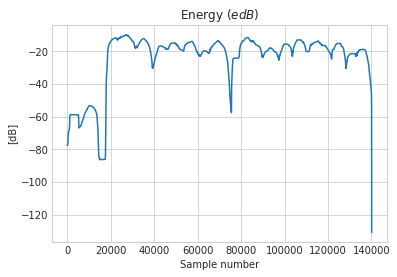

In [12]:
show(edB, title="Energy ($edB$)", ylabel="[dB]", xlabel="Sample number")

In [13]:
printmd("### 3.2.1 Calculated parameters")
printmd("**$d_{max}$** = " + f"{edBmax} dB")
printmd("**$d_{min}$** = " + f"{edBmin} dB" + f" (_when the maximum dynamic range considered is {MAX_DYNAMIC_RANGE} dB_)")

### 3.2.1 Calculated parameters

**$d_{max}$** = -9.842206542203712 dB

**$d_{min}$** = -86.32730445083465 dB (_when the maximum dynamic range considered is 90 dB_)

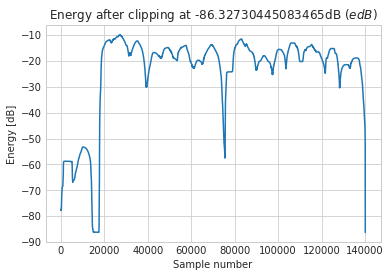

In [14]:
show(edB_clipped, title=f"Energy after clipping at {edBmin}dB ($edB$)", ylabel=f"Energy [dB]", xlabel="Sample number")

### The majority filter

In [15]:
def boolean_majority_filter(y, window_size):
    """
        Applies a majority filter boolean vectors
        over windows of size 2 * window_size + 1 
    """
    y_out = y.copy()

    # we initalize the sentry as N True values. This makes the edges of the sound be considered as
    # noise more often, which is more common anyway.
    y_pad = np.concatenate(
        (np.ones(window_size), y, np.ones(window_size + 1)))

    n_true = 0
    n_false = 0

    for i in range(2 * window_size + 1):
        n_true += int(y_pad[i])
        n_false += int(not y_pad[i])

    for i in range(len(y_out)):
        # Every index is the majority vote of the window y[i-window_size : i+window_size + 1]
        # containing 2 * window_size + 1 elements.
        # that corresponds to indexes y_pad[i:i + 2 * window_size + 1]
        y_out[i] = n_true > n_false

        if i >= window_size:
            to_remove = y_out[i - window_size]
        else:  # remove one "True" that we padded.
            to_remove = y_pad[i]

        if to_remove:
            n_true -= 1
        else:
            n_false -= 1

        # gets the new vote and includes it.
        if y_pad[i + 2 * window_size + 1]:
            n_true += 1
        else:
            n_false += 1

    return y_out

### Experimental calculated paramenters

Same as in section 3.2.1.

In [16]:
#     def noise_sel(self, y, sr, noise_threshold: float = None):
#         edB, edBmin, edBmax = self.__sliding_window_energy(y, sr)

#         noise_threshold = self.noise_threshold_db
#         if noise_threshold is None:
#             noise_threshold = self.noise_threshold_pct * (edBmax - edBmin)

#         # select frames with RMS mean next to the minimum level
#         is_noise_pre = edB < edBmin + noise_threshold

#         window_size = self.bool_filter_window_size or 0.2 * sr

#         is_noise = self.__boolean_majority_filter(is_noise_pre, int(window_size))

#         return is_noise, is_noise_pre

def noise_sel(y):
    noise_threshold = NOISE_THRESHOLD_DB
    if noise_threshold is None:
        noise_threshold = NOISE_THRESHOLD_PCT * (edBmax - edBmin)

    is_noise_pre = np.ones(len(edB)) * (edB < edBmin + noise_threshold)

    window_size = BOOL_FILTER_WINDOW_SIZE or 0.2 * SAMPLE_RATE
    is_noise = boolean_majority_filter(is_noise_pre, int(window_size))
    
    return noise_threshold, is_noise, is_noise_pre

noise_threshold, is_noise, is_noise_pre = noise_sel(y_without_dc)

In [17]:
printmd(r"$\alpha d_{diff}$ = " + f"{noise_threshold} dB")
printmd(r"$\epsilon = d_{min} + \alpha_{diff}$ = " + f"{edBmin + noise_threshold} dB")

$\alpha d_{diff}$ = 20.650976435330353 dB

$\epsilon = d_{min} + \alpha_{diff}$ = -65.6763280155043 dB

In [18]:
#     def __cut_noise_from_edges(self, y, is_noise):
#         """
#             Cuts all the noise from the beginning and end of the signal.
#             this is made using the indices of inoise.
#         """
#         # noise = True, signal = False. It returns rows and columns, we just want the rows.
#         isignal, *_ = np.where(is_noise == False)
#         first_signal, last_signal = isignal[0], isignal[-1]

#         return y[first_signal:last_signal]

def cut_noise_from_edges(y, is_noise):
    isignal, *_ = np.where(is_noise == False)
    first_signal, last_signal = isignal[0], isignal[-1]

    return first_signal, last_signal, y[first_signal:last_signal]
    
first_signal, last_signal, edB_stripped = cut_noise_from_edges(edB_clipped, is_noise)

### Putting everything together

In [19]:
# Just for visualization matters
speech_pre_box = is_noise_pre * np.min(edB_clipped)
speech_box = is_noise * np.min(edB_clipped)
x = np.arange(0, len(edB)/SAMPLE_RATE, 1/SAMPLE_RATE)

In [20]:
def plot_results():
    
    plt.figure()

    # Energy
    plt.plot(np.arange(first_signal/SAMPLE_RATE, last_signal/SAMPLE_RATE, 1/SAMPLE_RATE), edB_stripped, 'b', label="Energy")
    plt.plot(x, edB_clipped, '--b', alpha=0.5, label="Stripped edges")

    # Noise threshold
    plt.plot(x, (edBmin + noise_threshold) * np.ones(len(edB)), 'r', label = "Calculated noise threshold")

    # Classification
    plt.plot(x, speech_pre_box, '--g', alpha=0.5, label="Classification before majority filter")
    plt.fill(x, speech_box, 'g', alpha=0.05, label="Classification after majority filter")

    # Plot
    plt.title("Segmentation results")
    plt.xlabel("[s]")
    plt.ylabel("Energy [dB]")
    plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
    plt.show()

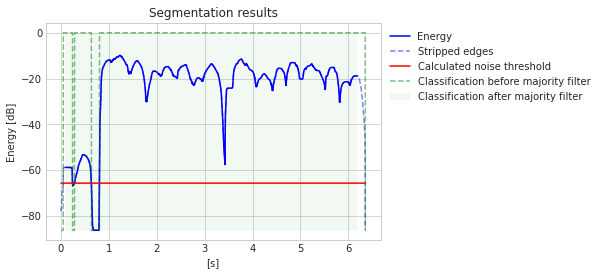

In [21]:
plot_results()

## What happens with a 4096 length sample?

Here we try to understand what happens if we slice the audio in small parts to feed a neural network.

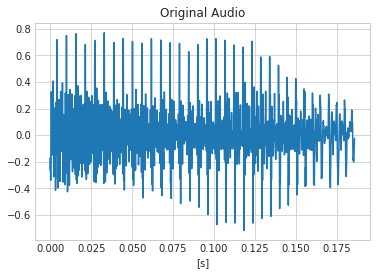

In [22]:
y, SAMPLE_RATE = librosa.load(filename)
y = y[int(len(y)/2):int(len(y)/2+4096)]
x = np.arange(0, len(y)/SAMPLE_RATE, 1/SAMPLE_RATE)

show(y, title="Original Audio", audio=True)

It breaks because:

```
        # we throw away the initial and ending 0.5s, because the sliding windows
        # are not correct in the initial/final borders.
```

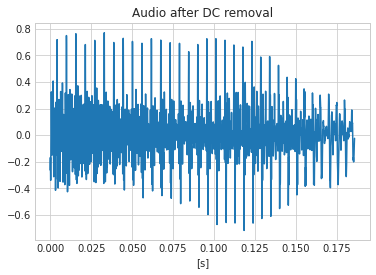

ValueError: zero-size array to reduction operation maximum which has no identity

In [23]:
# Calculations
y_without_dc = remove_dc(y)
edB, edB_clipped, edBmax, edBmin = sliding_window_energy(y_without_dc)
noise_threshold, is_noise, is_noise_pre = noise_sel(y_without_dc)
first_signal, last_signal, edB_stripped = cut_noise_from_edges(edB_clipped, is_noise)

# Visualization
speech_pre_box = is_noise_pre * np.min(edB_clipped)
speech_box = is_noise * np.min(edB_clipped)
x = np.arange(0, len(edB)/SAMPLE_RATE, 1/SAMPLE_RATE)

plot_results()